# 🎲 The Monty Hall Problem — Deterministic Logic Meets Monte Carlo

## Project Goal

This notebook explores the classic Monty Hall problem from *Let's Make a Deal*.

There are three doors:
- Behind one door: a car 🚗
- Behind two doors: goats 🐐

You choose a door.
The host, who knows where the car is, opens one of the remaining doors revealing a goat.
You are given the option to **stay** with your original choice or **switch**.

The central question:

> Does switching increase your probability of winning?

---

## Phase 1 — Deterministic Argument

We will:
1. Derive the exact probabilities using pure logic.
2. Show why switching yields a 2/3 probability of winning.
3. Demonstrate why staying yields only 1/3.

No randomness yet. Just airtight reasoning.

---

## Phase 2 — Confidence and Sample Size

We will:
1. Treat the game as a Bernoulli process.
2. Determine how many simulated games are required to detect the difference between 1/3 and 2/3.
3. Compute required sample sizes for:
   - 50% confidence
   - 75% confidence
   - 90% confidence
   - 95% confidence

---

## Phase 3 — Monte Carlo Simulation

We will:
1. Simulate the game thousands (and eventually millions) of times.
2. Compare empirical results to theoretical results.
3. Show convergence.
4. Demonstrate how confidence grows with sample size.

---

This notebook will move from pure reasoning to statistical validation.

No magic. No hand-waving.

Just probability doing what probability does.

In [4]:
import sys
import os
import importlib
import platform
from pathlib import Path

print("\n==============================")
print("🔎 Jupyter Environment Check")
print("==============================\n")

# 1️⃣ Python executable location
print("📍 Python Executable:")
print(sys.executable)
print()

# 2️⃣ Virtual environment detection
venv_active = (
    hasattr(sys, "real_prefix") or
    (hasattr(sys, "base_prefix") and sys.base_prefix != sys.prefix)
)

print("📦 Virtual Environment Active:", venv_active)
print("   sys.prefix:", sys.prefix)
print("   sys.base_prefix:", sys.base_prefix)
print()

# 3️⃣ Check expected venv name (optional but helpful)
expected_env_name = ".venv"

if expected_env_name in sys.executable:
    print("✅ Running inside expected .venv")
else:
    print("⚠️ WARNING: Not running inside expected .venv")
    print("   Expected path to include:", expected_env_name)
    print()

# 4️⃣ OS + Version
print("🖥 System Info:")
print("   OS:", platform.system(), platform.release())
print("   Python Version:", sys.version)
print()

# 5️⃣ Required packages check
required_packages = ["numpy", "matplotlib", "scipy", "ipykernel"]

print("📚 Package Verification:")
missing = []

for pkg in required_packages:
    try:
        importlib.import_module(pkg)
        print(f"   ✅ {pkg}")
    except ImportError:
        print(f"   ❌ {pkg} (NOT INSTALLED)")
        missing.append(pkg)

print()

# 6️⃣ Fix instructions if needed
if missing:
    print("🚨 Missing packages detected.")
    print("To fix, run this in PowerShell inside your activated venv:\n")
    print(f"pip install {' '.join(missing)}\n")
else:
    print("🎉 All required packages are installed.")

# 7️⃣ Final verdict
if venv_active and not missing and expected_env_name in sys.executable:
    print("\n🏁 ENVIRONMENT STATUS: GOOD TO GO 🚀")
else:
    print("\n⚠️ ENVIRONMENT STATUS: NEEDS ATTENTION")
    print("Re-check your kernel selection in VS Code.")


🔎 Jupyter Environment Check

📍 Python Executable:
c:\Users\evertj\git\SwosuCsPythonExamples\Discrete_Structures\Ch07\.venv\Scripts\python.exe

📦 Virtual Environment Active: True
   sys.prefix: c:\Users\evertj\git\SwosuCsPythonExamples\Discrete_Structures\Ch07\.venv
   sys.base_prefix: C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0

✅ Running inside expected .venv
🖥 System Info:
   OS: Windows 10
   Python Version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]

📚 Package Verification:
   ✅ numpy
   ✅ matplotlib
   ✅ scipy
   ✅ ipykernel

🎉 All required packages are installed.

🏁 ENVIRONMENT STATUS: GOOD TO GO 🚀


🧠 Optional: Nuclear Self-Repair Version

If you want it to auto-install missing packages inside the notebook (not always ideal for teaching but powerful), replace the missing section with:

```bash
import subprocess

for pkg in missing:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
```
But I recommend keeping repair in PowerShell.
Better pedagogy.

# Phase 1 — Deterministic Argument

Before running a single simulation, we will prove the answer using pure logic.

There are three doors:
- 1 car
- 2 goats

When you first choose a door:

- Probability the car is behind your chosen door = 1/3
- Probability the car is behind one of the *other two doors* = 2/3

The host then:
- Opens one of the two unchosen doors
- Always reveals a goat
- Never reveals the car

Key insight:

The host’s action does NOT redistribute probability.
It concentrates the entire 2/3 probability mass onto the one unopened door.

Therefore:
- Staying keeps your original 1/3 chance.
- Switching gives you the full 2/3 chance.

We will now compute this explicitly.

In [ ]:
print("\n==============================")
print("Deterministic Monty Hall Logic")
print("==============================\n")

# Total doors
total_doors = 3

# Probability of picking car initially
prob_initial_correct = 1 / total_doors

# Probability car is in the other doors
prob_initial_wrong = 1 - prob_initial_correct

print(f"Total doors: {total_doors}")
print(f"Probability your first pick is correct: {prob_initial_correct:.3f}")
print(f"Probability your first pick is wrong: {prob_initial_wrong:.3f}")
print()

print("After host reveals a goat:")
print("Host NEVER reveals the car.")
print()

prob_stay = prob_initial_correct
prob_switch = prob_initial_wrong

print(f"Probability of winning if you STAY:   {prob_stay:.3f}")
print(f"Probability of winning if you SWITCH: {prob_switch:.3f}")
print()

if prob_switch > prob_stay:
    print("Conclusion: Switching doubles your probability of winning.")
else:
    print("Something is wrong with the universe.")


Deterministic Monty Hall Logic

Total doors: 6
Probability your first pick is correct: 0.167
Probability your first pick is wrong: 0.833

After host reveals a goat:
Host NEVER reveals the car.

Probability of winning if you STAY:   0.167
Probability of winning if you SWITCH: 0.833

Conclusion: Switching doubles your probability of winning.


# Why the Host Changes Everything (But Actually Changes Nothing)

The host’s knowledge is the entire engine of the puzzle.

Step-by-step reasoning:

1. You choose one door.
   - You have a 1/3 chance of being correct.
   - You have a 2/3 chance of being wrong.

2. The host opens a goat door.
   - He NEVER reveals the car.
   - He ALWAYS reveals a goat.
   - He is constrained by the true location of the prize.

This action does not change your original probability.
It simply eliminates one losing possibility.

If your original choice was wrong (2/3 chance),
then the remaining unopened door MUST contain the car.

Therefore:
- Staying wins only when your original guess was correct (1/3).
- Switching wins whenever your original guess was wrong (2/3).

The host acts like a probability funnel.
He collapses two doors into one — without redistributing the probability mass.

No randomness was required for this argument.

This is pure conditional probability.

The Monte Carlo simulation later will not *discover* the truth.

It will simply confirm what logic already proved.

# Sidebar Experiment — Coin Flips and Confidence Intervals

Before tackling Monty Hall, we explore a simpler case:
a fair coin.

True probability of heads:

\[
p = 0.5
\]

If we flip a coin \( n \) times and observe \( \hat{p} \) heads, then:

\[
\hat{p} = \frac{\text{Number of Heads}}{n}
\]

This is our **sample proportion**.

---

## Expected Value

For a fair coin:

\[
E[\hat{p}] = p = 0.5
\]

As \( n \) increases, the Law of Large Numbers tells us:

\[
\hat{p} \to 0.5
\]

---

## Confidence Interval for a Proportion

For large enough \( n \), the sampling distribution of \( \hat{p} \) is approximately normal:

\[
\hat{p} \sim N\left(p, \frac{p(1-p)}{n}\right)
\]

The standard error is:

\[
SE = \sqrt{\frac{p(1-p)}{n}}
\]

A confidence interval at level \( 1 - \alpha \) is:

\[
\hat{p} \pm z_{\alpha/2} \cdot SE
\]

For 95% confidence:

\[
z_{0.025} = 1.96
\]

Notice the width depends on:

\[
\frac{1}{\sqrt{n}}
\]

So confidence intervals shrink as \( n \) increases.

We will now simulate one growing experiment:
n = 1 to 20 flips,
track \( \hat{p} \),
and plot the 95% confidence interval.

# Where Does the z-Score Come From?

We used:

\[
z = \text{norm.ppf}(0.975)
\]

But what does that mean?

---

## Step 1 — The Standard Normal Distribution

When sample size is large, the sampling distribution of a proportion is approximately:

\[
\hat{p} \sim N\left(p, \frac{p(1-p)}{n}\right)
\]

If we standardize this distribution, we get:

\[
Z = \frac{\hat{p} - p}{\sqrt{p(1-p)/n}}
\]

This follows the **standard normal distribution**:

\[
Z \sim N(0, 1)
\]

---

## Step 2 — Confidence Level and Alpha

Suppose we want a 95% confidence interval.

That means:

\[
P(\text{estimate is within bounds}) = 0.95
\]

The remaining probability is:

\[
\alpha = 1 - 0.95 = 0.05
\]

Since confidence intervals are two-sided, we split this evenly:

\[
\alpha / 2 = 0.025
\]

So we want the z-value such that:

\[
P(Z < z) = 1 - 0.025 = 0.975
\]

---

## Step 3 — Using the Inverse CDF

The function:

\[
\text{norm.ppf}(x)
\]

means:

> Percent Point Function  
> The inverse cumulative distribution function.

It answers:

"What z-value has cumulative probability x?"

So:

\[
z = \text{norm.ppf}(0.975)
\]

returns:

\[
z \approx 1.96
\]

---

## Step 4 — Why 1.96?

Because:

\[
P(-1.96 < Z < 1.96) \approx 0.95
\]

That is the mathematical definition of a 95% confidence interval.

---

## General Formula

For any confidence level \( C \):

1. Compute:
\[
\alpha = 1 - C
\]

2. Divide by 2:
\[
\alpha/2
\]

3. Compute:
\[
z = \text{norm.ppf}(1 - \alpha/2)
\]

---

### Examples

| Confidence | z-value |
|------------|---------|
| 50% | 0.674 |
| 75% | 1.150 |
| 90% | 1.645 |
| 95% | 1.960 |
| 99% | 2.576 |

These are not magic numbers.

They are quantiles of the standard normal distribution.

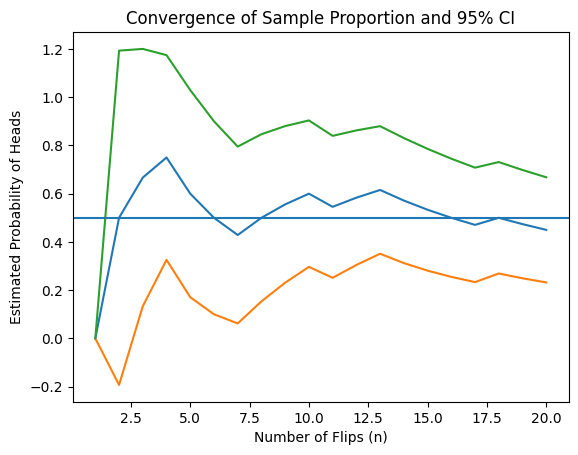

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

true_p = 0.5
max_n = 20
z = norm.ppf(0.975)  # 95% confidence

flip_results = np.random.binomial(1, true_p, max_n)

sample_props = []
lower_bounds = []
upper_bounds = []

heads_count = 0

for n in range(1, max_n + 1):
    heads_count += flip_results[n - 1]
    p_hat = heads_count / n
    sample_props.append(p_hat)

    se = np.sqrt(p_hat * (1 - p_hat) / n) if n > 1 else 0
    margin = z * se

    lower_bounds.append(p_hat - margin)
    upper_bounds.append(p_hat + margin)

n_values = np.arange(1, max_n + 1)

plt.figure()
plt.plot(n_values, sample_props)
plt.plot(n_values, lower_bounds)
plt.plot(n_values, upper_bounds)
plt.axhline(true_p)
plt.xlabel("Number of Flips (n)")
plt.ylabel("Estimated Probability of Heads")
plt.title("Convergence of Sample Proportion and 95% CI")
plt.show()

# Sample Size Required vs Confidence Level

We want to determine:

How many trials (n) are required to estimate a proportion with a given confidence level?

---

## Starting Point: Confidence Interval for a Proportion

For large n:

\[
\hat{p} \pm z_{\alpha/2} \cdot \sqrt{\frac{p(1-p)}{n}}
\]

The **margin of error (E)** is:

\[
E = z_{\alpha/2} \cdot \sqrt{\frac{p(1-p)}{n}}
\]

---

## Solve for n

Rearranging:

\[
n = \frac{z_{\alpha/2}^2 \, p(1-p)}{E^2}
\]

Where:

- \( z_{\alpha/2} \) depends on confidence level
- \( p \) is the true proportion
- \( E \) is acceptable margin of error

---

## For a Fair Coin

Worst-case variance occurs at:

\[
p = 0.5
\]

because:

\[
p(1-p)
\]

is maximized at 0.25.

Using this gives a conservative estimate for required sample size.

---

We will now compute required n for:

- 50% confidence
- 75% confidence
- 90% confidence
- 95% confidence

Assume:

Margin of error:
\[
E = 0.05
\]

Meaning:
We want our estimate within ±5 percentage points.

Confidence Level: 50%
  z-score: 0.674
  Required Sample Size (n): 46

Confidence Level: 75%
  z-score: 1.150
  Required Sample Size (n): 133

Confidence Level: 90%
  z-score: 1.645
  Required Sample Size (n): 271

Confidence Level: 95%
  z-score: 1.960
  Required Sample Size (n): 385



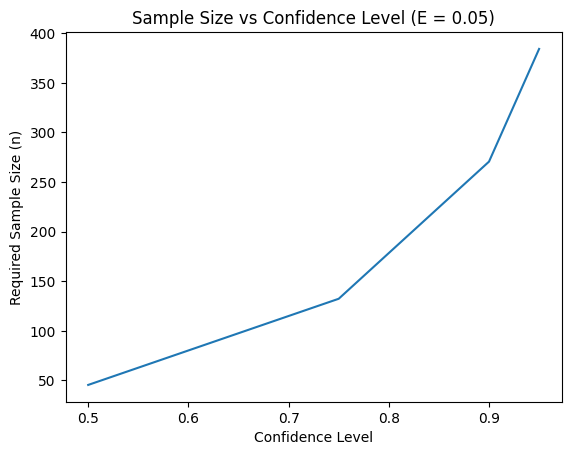

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
p = 0.5
E = 0.05

confidence_levels = np.array([0.50, 0.75, 0.90, 0.95])
z_scores = norm.ppf(1 - (1 - confidence_levels) / 2)

required_n = (z_scores**2 * p * (1 - p)) / (E**2)

for cl, z, n in zip(confidence_levels, z_scores, required_n):
    print(f"Confidence Level: {cl:.0%}")
    print(f"  z-score: {z:.3f}")
    print(f"  Required Sample Size (n): {int(np.ceil(n))}")
    print()

# Plot
plt.figure()
plt.plot(confidence_levels, required_n)
plt.xlabel("Confidence Level")
plt.ylabel("Required Sample Size (n)")
plt.title("Sample Size vs Confidence Level (E = 0.05)")
plt.show()

# Why This Matters

Notice the curve is NOT linear.

Sample size grows roughly with:

\[
z^2
\]

As confidence increases:

- z increases nonlinearly
- n increases quadratically

Going from:
- 90% to 95% confidence

costs disproportionately more samples than:
- 50% to 75%

This is a fundamental truth in statistics:

Certainty is expensive.

---

## Why This Is Critical for Monty Hall

In Monty Hall:

- Stay = 1/3
- Switch = 2/3

The difference is large (≈ 0.333).

That means:
We do NOT need millions of simulations
to detect the effect with high confidence.

But if the difference were small,
required n would explode.

Understanding this prepares us to:

1. Predict how many Monte Carlo runs we need
2. Avoid over-simulating
3. Teach students why brute force without theory is inefficient

We now have:

- Deterministic truth
- Confidence math
- Sample size logic

Next:

We simulate Monty Hall
and watch convergence in action.